In [3]:
# # REINFORCE with Baseline - Hello World
# 
# This notebook demonstrates the REINFORCE algorithm with baseline on the CartPole environment.
# REINFORCE is a policy gradient method that learns a policy directly by using the gradient
# of expected rewards. The baseline helps reduce variance in the gradient estimates.

# %%
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import gymnasium as gym
from collections import deque
import random

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


In [5]:

# ## Policy and Value Networks
# 
# We'll create separate networks: one for the policy (action selection) and one for 
# the state-value function (baseline). This separation is more theoretically sound
# and allows for different learning rates and architectures.

# %%
class PolicyNetwork(nn.Module):
    def __init__(self, state_size, action_size, hidden_size=128):
        super(PolicyNetwork, self).__init__()
        
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_size)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        action_logits = self.fc3(x)
        action_probs = F.softmax(action_logits, dim=-1)
        return action_probs

class ValueNetwork(nn.Module):
    def __init__(self, state_size, hidden_size=128):
        super(ValueNetwork, self).__init__()
        
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        value = self.fc3(x)
        return value

# %%
# Initialize environment and networks
env = gym.make('CartPole-v1')
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print(f"State size: {state_size}")
print(f"Action size: {action_size}")

# Create separate policy and value networks
policy_net = PolicyNetwork(state_size, action_size)
value_net = ValueNetwork(state_size)

# Separate optimizers for policy and value networks
policy_optimizer = optim.Adam(policy_net.parameters(), lr=0.01)
value_optimizer = optim.Adam(value_net.parameters(), lr=0.01)

print("Policy and Value networks initialized!")

State size: 4
Action size: 2
Policy and Value networks initialized!


In [6]:
# ## REINFORCE with Baseline Agent

# %%
class REINFORCEAgent:
    def __init__(self, policy_net, value_net, policy_optimizer, value_optimizer, gamma=0.99):
        self.policy_net = policy_net
        self.value_net = value_net
        self.policy_optimizer = policy_optimizer
        self.value_optimizer = value_optimizer
        self.gamma = gamma
        
        # Storage for episode data
        self.reset_episode()
        
    def reset_episode(self):
        """Reset episode-specific storage"""
        self.log_probs = []
        self.values = []
        self.rewards = []
        self.states = []
        
    def select_action(self, state):
        """Select action using current policy"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        
        # Get action probabilities from policy network
        action_probs = self.policy_net(state_tensor)
        
        # Get state value from value network
        value = self.value_net(state_tensor)
        
        # Create categorical distribution and sample action
        dist = Categorical(action_probs)
        action = dist.sample()
        
        # Store data for training
        self.log_probs.append(dist.log_prob(action))
        self.values.append(value)
        self.states.append(state_tensor)
        
        return action.item()
    
    def compute_returns(self):
        """Compute discounted returns for each timestep"""
        returns = []
        G = 0
        
        # Compute returns backwards from the end of episode
        for reward in reversed(self.rewards):
            G = reward + self.gamma * G
            returns.insert(0, G)
            
        return torch.FloatTensor(returns)
    
    def update_policy(self):
        """Update policy and value networks separately"""
        if len(self.rewards) == 0:
            return 0, 0
            
        # Compute returns
        returns = self.compute_returns()
        
        # Convert stored values to tensors
        log_probs = torch.stack(self.log_probs)
        values = torch.stack(self.values).squeeze()
        
        # Compute advantages (returns - baseline)
        advantages = returns - values.detach()  # Detach to avoid affecting value loss
        
        # Normalize advantages for stability
        if advantages.std() > 1e-8:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        # Update Policy Network
        policy_loss = -(log_probs * advantages).mean()
        
        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        self.policy_optimizer.step()
        
        # Update Value Network (multiple updates for better baseline)
        value_loss = 0
        for _ in range(5):  # Multiple value updates per policy update
            # Re-compute values for current parameters
            current_values = torch.stack([self.value_net(state) for state in self.states]).squeeze()
            v_loss = F.mse_loss(current_values, returns)
            
            self.value_optimizer.zero_grad()
            v_loss.backward()
            self.value_optimizer.step()
            
            value_loss = v_loss.item()  # Store the last loss for reporting
        
        return policy_loss.item(), value_loss


REINFORCE agent created with separate policy and value networks!
Starting training...
Episode 0, Average Reward: 20.00
Episode 100, Average Reward: 18.12
Episode 200, Average Reward: 15.58
Episode 300, Average Reward: 13.61
Episode 400, Average Reward: 11.58
Training completed!


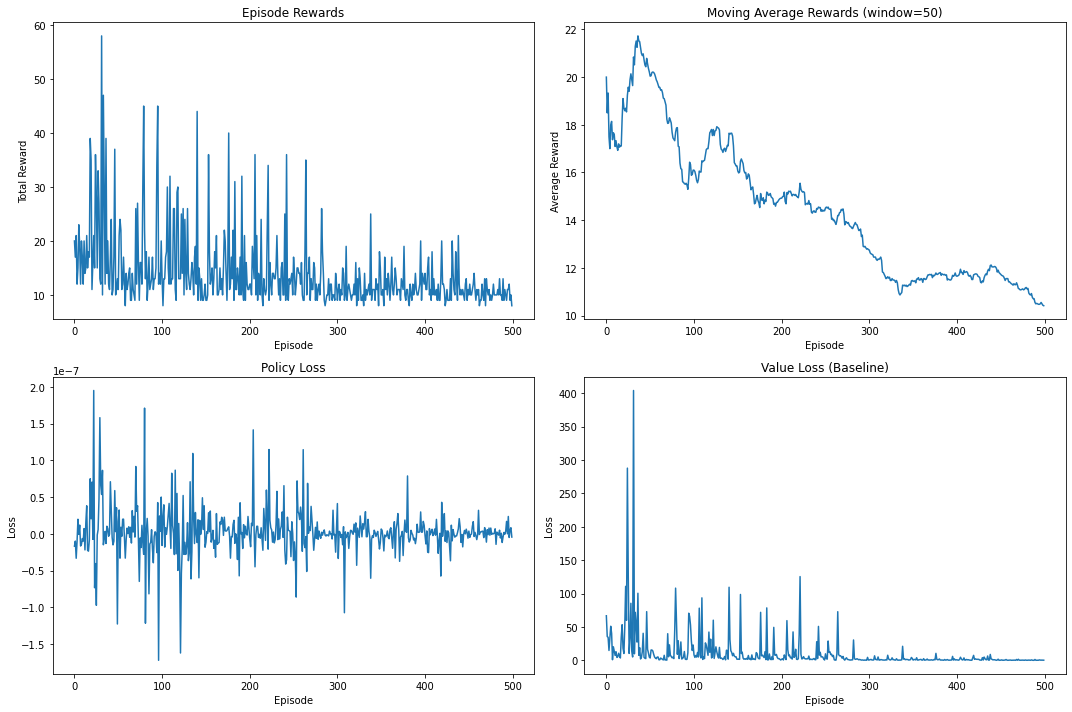

In [7]:

# Create agent
agent = REINFORCEAgent(policy_net, value_net, policy_optimizer, value_optimizer)
print("REINFORCE agent created with separate policy and value networks!")

# %% [markdown]
# ## Training Loop

# %%
def train_reinforce(agent, env, num_episodes=1000):
    """Train the REINFORCE agent"""
    episode_rewards = []
    policy_losses = []
    value_losses = []
    
    for episode in range(num_episodes):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]  # Handle new gym API
            
        agent.reset_episode()
        episode_reward = 0
        
        # Run episode
        while True:
            action = agent.select_action(state)
            result = env.step(action)
            
            if len(result) == 4:  # Old gym API
                next_state, reward, done, _ = result
            else:  # New gym API
                next_state, reward, terminated, truncated, _ = result
                done = terminated or truncated
            
            agent.rewards.append(reward)
            episode_reward += reward
            
            if done:
                break
                
            state = next_state
        
        # Update policy after episode
        policy_loss, value_loss = agent.update_policy()
        
        # Store metrics
        episode_rewards.append(episode_reward)
        policy_losses.append(policy_loss)
        value_losses.append(value_loss)
        
        # Print progress
        if episode % 100 == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            print(f"Episode {episode}, Average Reward: {avg_reward:.2f}")
    
    return episode_rewards, policy_losses, value_losses

# %%
print("Starting training...")
episode_rewards, policy_losses, value_losses = train_reinforce(agent, env, num_episodes=500)
print("Training completed!")

# %% [markdown]
# ## Results Visualization

# %%
# Plot training results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Episode rewards
axes[0, 0].plot(episode_rewards)
axes[0, 0].set_title('Episode Rewards')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')

# Moving average of rewards
window = 50
moving_avg = [np.mean(episode_rewards[max(0, i-window):i+1]) for i in range(len(episode_rewards))]
axes[0, 1].plot(moving_avg)
axes[0, 1].set_title(f'Moving Average Rewards (window={window})')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Average Reward')

# Policy losses
axes[1, 0].plot(policy_losses)
axes[1, 0].set_title('Policy Loss')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('Loss')

# Value losses
axes[1, 1].plot(value_losses)
axes[1, 1].set_title('Value Loss (Baseline)')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('Loss')

plt.tight_layout()
plt.show()

In [8]:

# Print final statistics
print(f"\nFinal Results:")
print(f"Average reward (last 100 episodes): {np.mean(episode_rewards[-100:]):.2f}")
print(f"Best episode reward: {max(episode_rewards):.2f}")

# %% [markdown]
# ## Test the Trained Agent

# %%
def test_agent(agent, env, num_episodes=5, render=False):
    """Test the trained agent"""
    test_rewards = []
    
    for episode in range(num_episodes):
        state = env.reset()
        if isinstance(state, tuple):
            state = state[0]
            
        episode_reward = 0
        steps = 0
        
        while True:
            if render:
                env.render()
                
            # Use deterministic policy for testing
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0)
                action_probs = agent.policy_net(state_tensor)
                action = torch.argmax(action_probs).item()
            
            result = env.step(action)
            if len(result) == 4:
                next_state, reward, done, _ = result
            else:
                next_state, reward, terminated, truncated, _ = result
                done = terminated or truncated
            
            episode_reward += reward
            steps += 1
            
            if done:
                break
                
            state = next_state
        
        test_rewards.append(episode_reward)
        print(f"Test Episode {episode + 1}: Reward = {episode_reward}, Steps = {steps}")
    
    return test_rewards

# %%
print("Testing trained agent...")
test_rewards = test_agent(agent, env, num_episodes=5)
print(f"\nTest Results:")
print(f"Average test reward: {np.mean(test_rewards):.2f}")
print(f"Test reward std: {np.std(test_rewards):.2f}")

# %%
env.close()
print("Environment closed. Training complete!")

# %% [markdown]
# ## Key Concepts Explained
# 
# ### REINFORCE Algorithm:
# 1. **Policy Gradient**: Updates policy parameters in direction of higher expected return
# 2. **Monte Carlo**: Uses full episode returns (no bootstrapping)
# 3. **Gradient**: ∇θ J(θ) ≈ E[∇θ log π(a|s) * G_t]
# 
# ### Baseline Benefits:
# 1. **Variance Reduction**: Subtracting baseline reduces gradient variance
# 2. **Faster Learning**: More stable updates lead to faster convergence
# 3. **Better Performance**: Lower variance enables higher learning rates
# 
# ### Implementation Details:
# - **Separate Networks**: Policy and value networks with independent parameters
# - **Independent Optimizers**: Different learning rates possible for policy vs value
# - **Multiple Value Updates**: Value network trained more frequently for better baseline
# - **Advantage Normalization**: Stabilizes training across different reward scales
# - **Detached Baselines**: Value estimates detached when computing policy gradients


Final Results:
Average reward (last 100 episodes): 11.08
Best episode reward: 58.00
Testing trained agent...
Test Episode 1: Reward = 10.0, Steps = 10
Test Episode 2: Reward = 8.0, Steps = 8
Test Episode 3: Reward = 9.0, Steps = 9
Test Episode 4: Reward = 9.0, Steps = 9
Test Episode 5: Reward = 9.0, Steps = 9

Test Results:
Average test reward: 9.00
Test reward std: 0.63
Environment closed. Training complete!
